# Cross validaition

TODO: description

## Imports

First we import the required packages and `feems`:

In [1]:
# base
import numpy as np
import pkg_resources
from sklearn.impute import SimpleImputer
from pandas_plink import read_plink
import statsmodels.api as sm
import igraph as ig

# viz
import matplotlib.pyplot as plt
from matplotlib import gridspec
import cartopy.crs as ccrs

# feems
from feems.utils import prepare_graph_inputs
from feems import SpatialGraph, Viz, Objective, query_node_attributes
from feems.cross_validation import run_cv, comp_mats

# change matplotlib fonts
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = "Arial"

/var/folders/tt/dl7vp5yn2fg110y175q2rf640000gn/T/ipykernel_96578/828904047.py:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/Users/matthewdesaix/mambaforge/envs/feems_e/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/Users/matthewdesaix/mambaforge/envs/feems_e/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


## Data

In [32]:
data_path = "/Users/matthewdesaix/Desktop/Local/Work/APHIS/GSMNP/data"

# read the genotype data and mean impute missing data
(bim, fam, G) = read_plink("{}/genotypes/buffer-10k/grsm-10k-final-571_10508".format(data_path))
imp = SimpleImputer(missing_values=np.nan, strategy="mean")
genotypes = imp.fit_transform((np.array(G)).T)

# setup graph
coord = np.loadtxt("{}/feems/grsm.10k.sample.coord".format(data_path))  # sample coordinates
outer = np.loadtxt("{}/feems/grsm.10k.boundary.outer".format(data_path))  # outer coordinates
grid_path = "{}/feems/dgg/grsm-dgg-spacing2.shp".format(data_path)  # path to discrete global grid

# graph input files
outer, edges, grid, _ = prepare_graph_inputs(coord=coord, 
                                             ggrid=grid_path,
                                             translated=True, 
                                             buffer=0,
                                             outer=outer)

# construct spatial graph object
sp_graph = SpatialGraph(genotypes, coord, grid, edges, scale_snps=True)

Mapping files: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 100.72it/s]


## Run cross-validation

Next we perform leave-one-out cross-valiation over a grid of $\lambda$ values. In our CV we hold out indivudal observed nodes on the graph, predict allele frequencies at the held-out node under our fitted model, and use the $\ell_2$ distance between the fitted and predicted allele frequencies as our CV metric to select models: 

In [33]:
%%time
# define grids
# reverse the order of lambdas and alphas for warmstart
lamb_grid = np.geomspace(1e-3, 1e3, 30)[::-1]

# run cross-validation
cv_err = run_cv(sp_graph, lamb_grid, n_folds=sp_graph.n_observed_nodes, factr=1e10)

# average over folds
mean_cv_err = np.mean(cv_err, axis=0)

# argmin of cv error
lamb_cv = float(lamb_grid[np.argmin(mean_cv_err)])


 fold= 0
iteration lambda=30/30 alpha=1/1
 fold= 1
iteration lambda=30/30 alpha=1/1
 fold= 2
iteration lambda=30/30 alpha=1/1
 fold= 3
iteration lambda=30/30 alpha=1/1
 fold= 4
iteration lambda=30/30 alpha=1/1
 fold= 5
iteration lambda=30/30 alpha=1/1
 fold= 6
iteration lambda=30/30 alpha=1/1
 fold= 7
iteration lambda=30/30 alpha=1/1
 fold= 8
iteration lambda=30/30 alpha=1/1
 fold= 9
iteration lambda=30/30 alpha=1/1
 fold= 10
iteration lambda=30/30 alpha=1/1
 fold= 11
iteration lambda=30/30 alpha=1/1
 fold= 12
iteration lambda=30/30 alpha=1/1
 fold= 13
iteration lambda=30/30 alpha=1/1
 fold= 14
iteration lambda=30/30 alpha=1/1
 fold= 15
iteration lambda=30/30 alpha=1/1
 fold= 16
iteration lambda=30/30 alpha=1/1
 fold= 17
iteration lambda=30/30 alpha=1/1
 fold= 18
iteration lambda=30/30 alpha=1/1
 fold= 19
iteration lambda=30/30 alpha=1/1
 fold= 20
iteration lambda=30/30 alpha=1/1
 fold= 21
iteration lambda=30/30 alpha=1/1
 fold= 22
iteration lambda=30/30 alpha=1/1
 fold= 23
iteration 

In [34]:
lamb_grid

array([1.00000000e+03, 6.21016942e+02, 3.85662042e+02, 2.39502662e+02,
       1.48735211e+02, 9.23670857e+01, 5.73615251e+01, 3.56224789e+01,
       2.21221629e+01, 1.37382380e+01, 8.53167852e+00, 5.29831691e+00,
       3.29034456e+00, 2.04335972e+00, 1.26896100e+00, 7.88046282e-01,
       4.89390092e-01, 3.03919538e-01, 1.88739182e-01, 1.17210230e-01,
       7.27895384e-02, 4.52035366e-02, 2.80721620e-02, 1.74332882e-02,
       1.08263673e-02, 6.72335754e-03, 4.17531894e-03, 2.59294380e-03,
       1.61026203e-03, 1.00000000e-03])

Plot CV error:

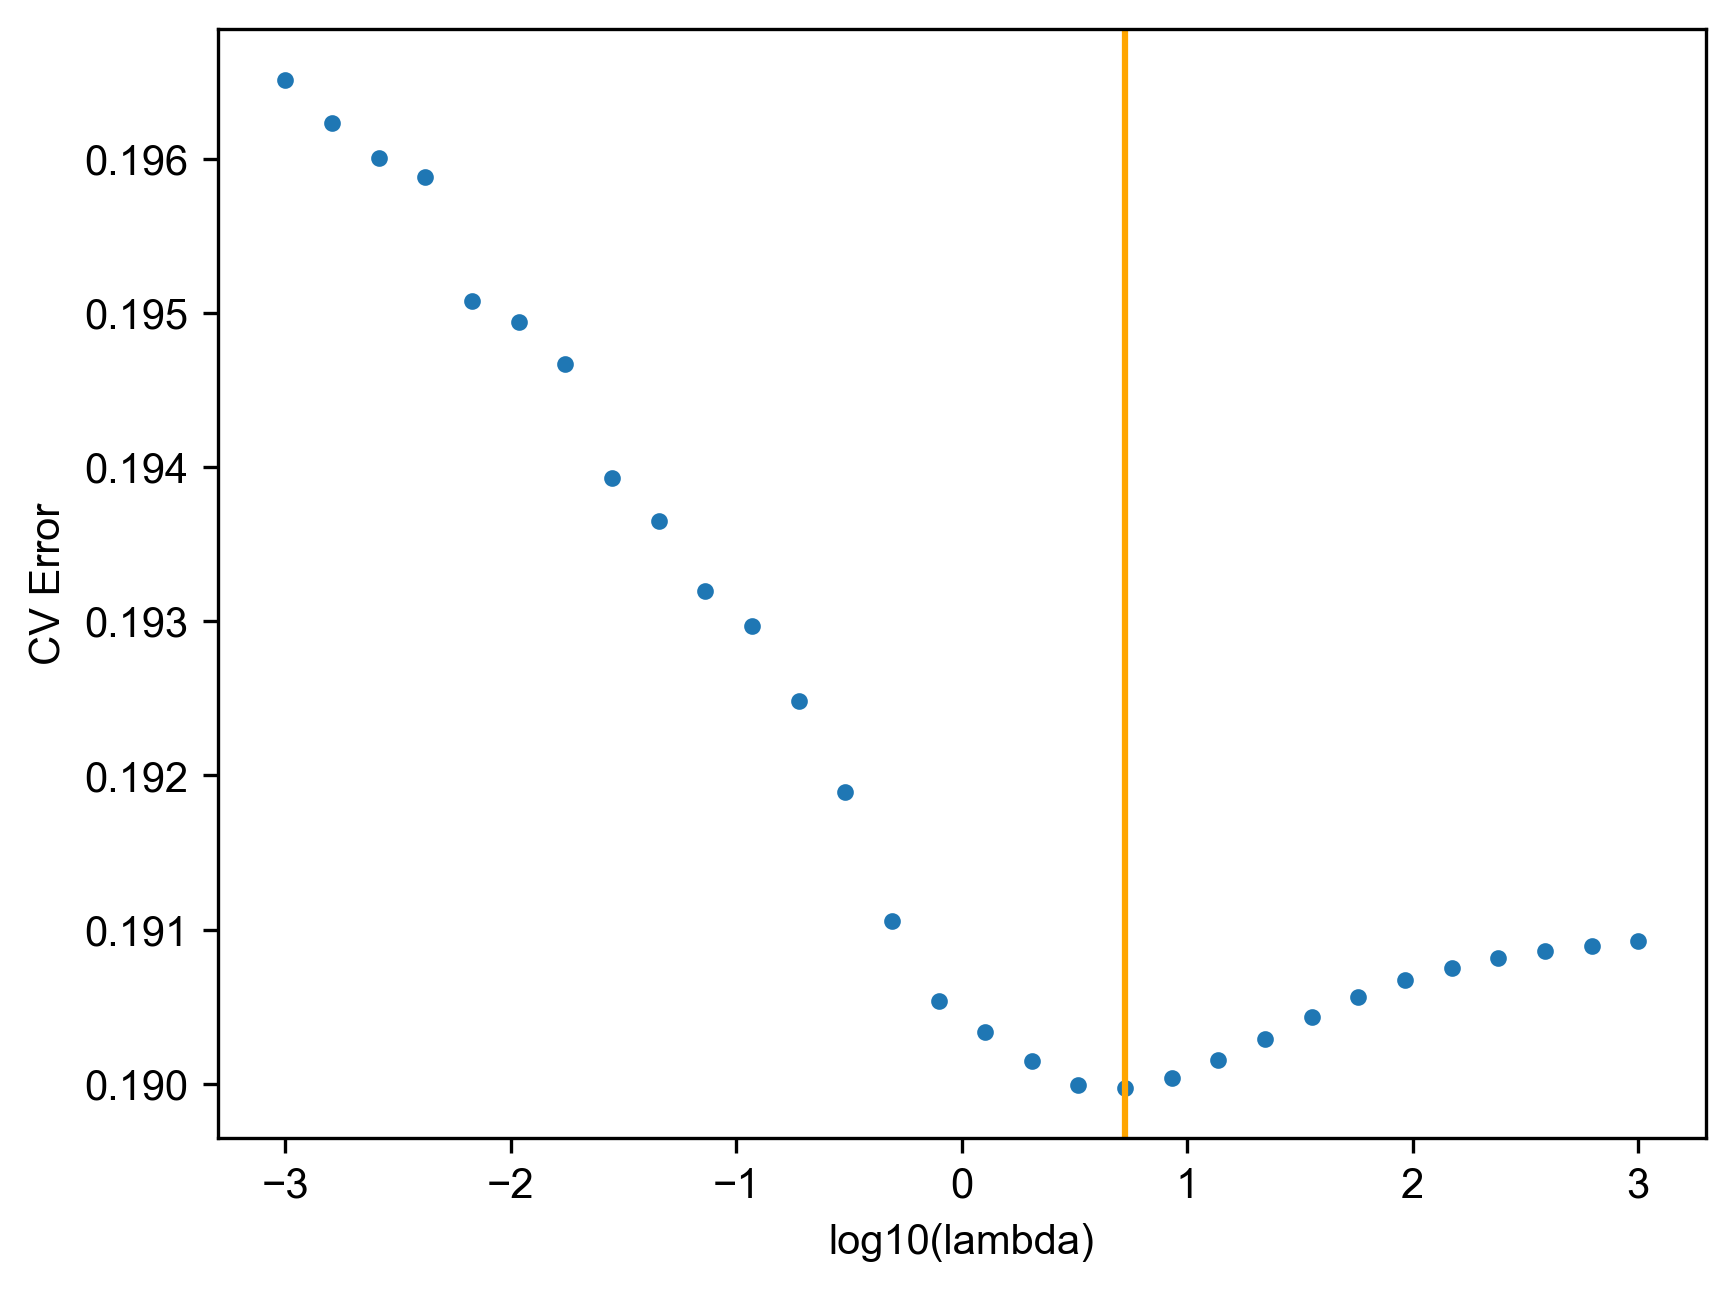

In [37]:
fig, ax = plt.subplots(dpi=300)
ax.plot(np.log10(lamb_grid), mean_cv_err, ".");
ax.set_xlabel("log10(lambda)");
ax.set_ylabel("CV Error");
ax.axvline(np.log10(lamb_cv), color = "orange")
plt.savefig("./plots/feems/dgg2/p.feems.dgg2.best_5.30_lambda_eval.png", transparent=False)

Lets take a look at a summary of CV:

constant-w/variance fit, converged in 116 iterations, train_loss=1149883.3027785
lambda=35.6224789, alpha=0.9151229, converged in 93 iterations, train_loss=1131540.4299129
constant-w/variance fit, converged in 116 iterations, train_loss=1149883.3027785
lambda=5.2983169, alpha=0.9151229, converged in 140 iterations, train_loss=1104674.4972719
constant-w/variance fit, converged in 116 iterations, train_loss=1149883.3027785
lambda=0.7880463, alpha=0.9151229, converged in 234 iterations, train_loss=1076339.6156253
CPU times: user 1min 33s, sys: 24.4 s, total: 1min 57s
Wall time: 12.5 s


Text(0.2, 0.85, 'lambda=0.78805\ncv error=0.19053')

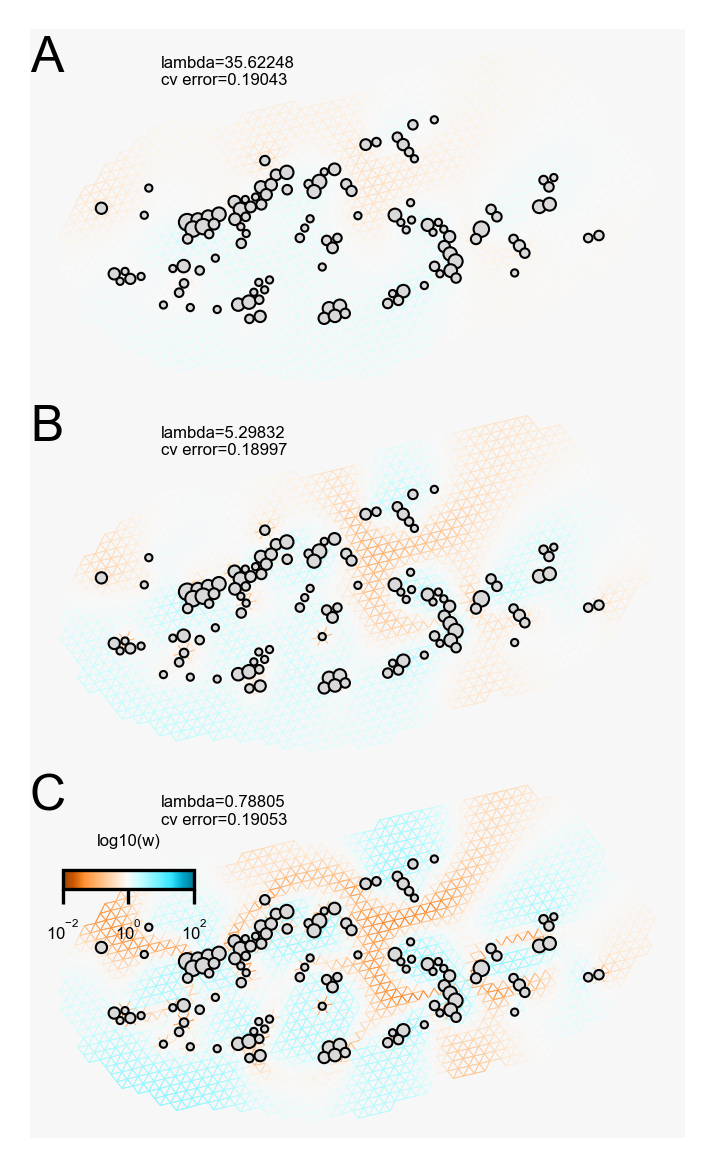

In [35]:
%%time
# figure params
projection = ccrs.EquidistantConic(central_longitude=-83.5, central_latitude=35.6)
title_loc = "left"
title_pad = "-10"
title_fontsize = 12
edge_width = .2
edge_alpha = 1
edge_zorder = 3
obs_node_size = 3
obs_node_linewidth = .4
cbar_font_size = 4
cbar_ticklabelsize = 4
cbar_orientation = "horizontal"

# figure setup
fig = plt.figure(dpi=300)
spec = gridspec.GridSpec(ncols=1, nrows=3, figure=fig, wspace=0.0, hspace=0.0)

# axis 00 
ax_00 = fig.add_subplot(spec[0, 0], projection=projection)
ax_00.set_title("A", loc=title_loc, pad=title_pad, fontdict={"fontsize": title_fontsize})
sp_graph.fit(float(lamb_grid[7]))
v = Viz(ax_00, sp_graph, projection=projection, edge_width=edge_width, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=obs_node_size, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map()
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False) 
ax_00.text(.2, .85, "lambda={:.5f}\ncv error={:.5f}".format(lamb_grid[7], mean_cv_err[7, 0]), 
           fontdict={"fontsize": 4}, transform = ax_00.transAxes)

# axis 10
ax_10 = fig.add_subplot(spec[1, 0], projection=projection)
ax_10.set_title("B", loc=title_loc, pad=title_pad, fontdict={"fontsize": title_fontsize})
sp_graph.fit(float(lamb_cv))
v = Viz(ax_10, sp_graph, projection=projection, edge_width=edge_width, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20,
        obs_node_size=obs_node_size, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map()
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False) 
ax_10.text(.2, .85, "lambda={:.5f}\ncv error={:.5f}".format(lamb_cv, mean_cv_err[np.argmin(mean_cv_err), 0]), 
           fontdict={"fontsize": 4}, transform = ax_10.transAxes)

# axis 20
ax_11 = fig.add_subplot(spec[2,0], projection=projection)
ax_11.set_title("C", loc=title_loc, pad=title_pad, fontdict={"fontsize": title_fontsize})
sp_graph.fit(float(lamb_grid[15]))
v = Viz(ax_11, sp_graph, projection=projection, edge_width=edge_width, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=obs_node_size, sample_pt_color="black", 
        cbar_font_size=6, cbar_loc="center left",
        cbar_height="5%", cbar_width="20%")
v.draw_map()
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False)
v.cbar_font_size = cbar_font_size
v.cbar_orientation = cbar_orientation
v.cbar_ticklabelsize = cbar_ticklabelsize
v.draw_edge_colorbar()
ax_11.text(.2, .85, "lambda={:.5f}\ncv error={:.5f}".format(lamb_grid[15], mean_cv_err[15, 0]), 
           fontdict={"fontsize": 4}, transform = ax_11.transAxes)

Lets zoom in on the fit that has the lowest error on the CV curve:

constant-w/variance fit, converged in 116 iterations, train_loss=1149883.3027785
lambda=5.2983169, alpha=0.9151229, converged in 140 iterations, train_loss=1104674.4972719


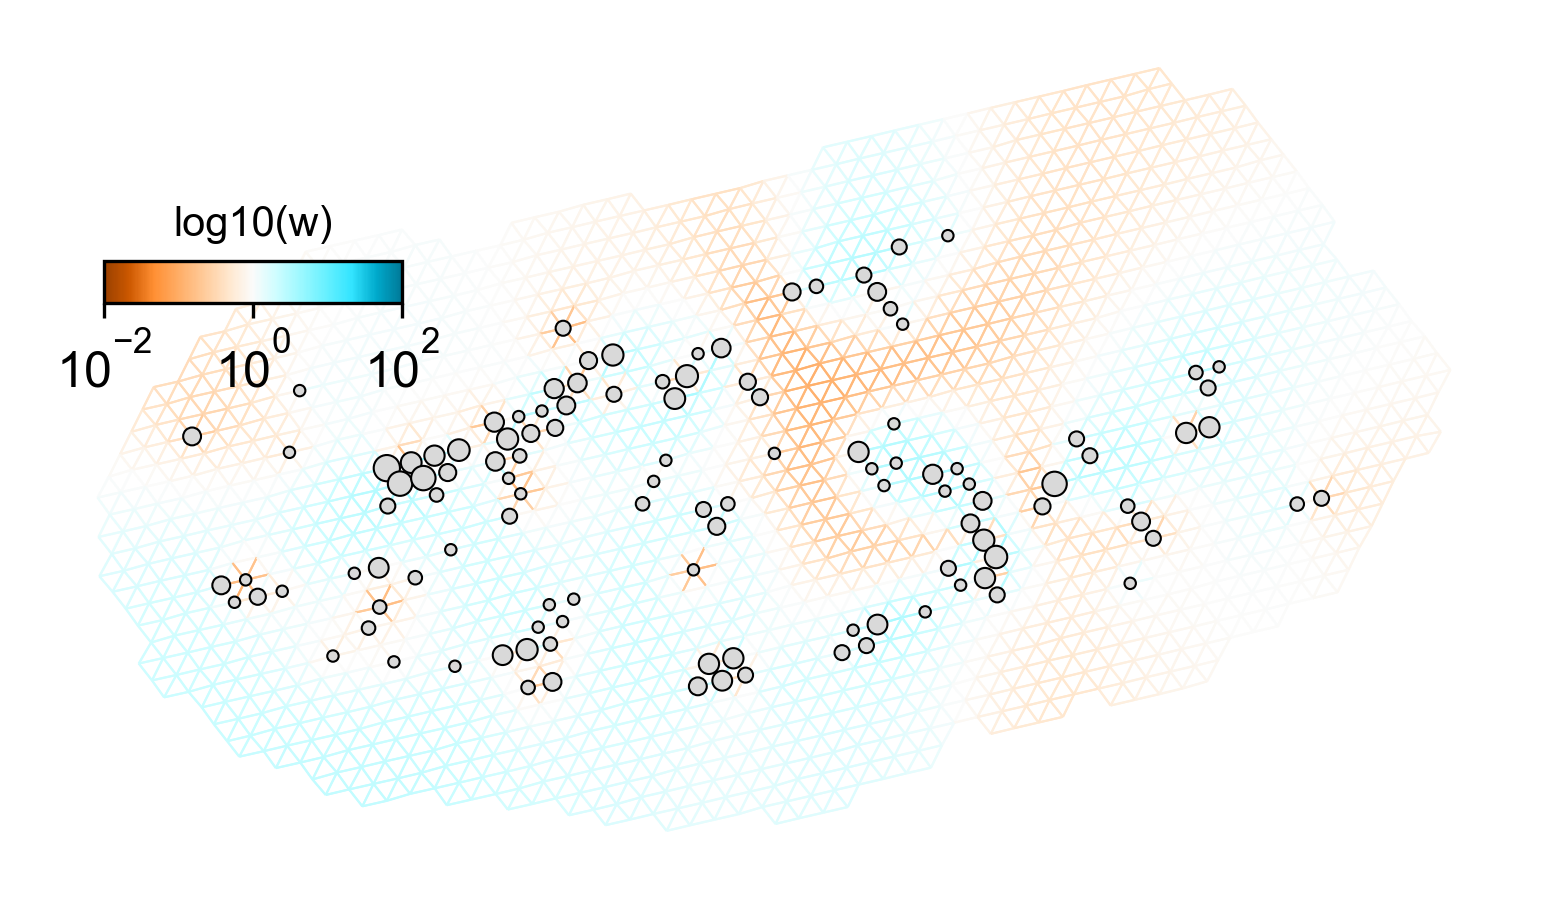

In [36]:
# re-fit
sp_graph.fit(float(lamb_cv))

# plot
fig = plt.figure(dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=projection)  
v = Viz(ax, sp_graph, projection=projection, edge_width=.5, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10, cbar_loc = "center left")
# v.draw_map()
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False) 
v.draw_edge_colorbar()

constant-w/variance fit, converged in 116 iterations, train_loss=1149883.3027785
constant-w/variance fit, converged in 116 iterations, train_loss=1149883.3027785
lambda=5.3000000, alpha=0.9151229, converged in 129 iterations, train_loss=1104679.6350705
constant-w/variance fit, converged in 116 iterations, train_loss=1149883.3027785
lambda=0.0053000, alpha=0.9151229, converged in 1876 iterations, train_loss=1034685.6790301


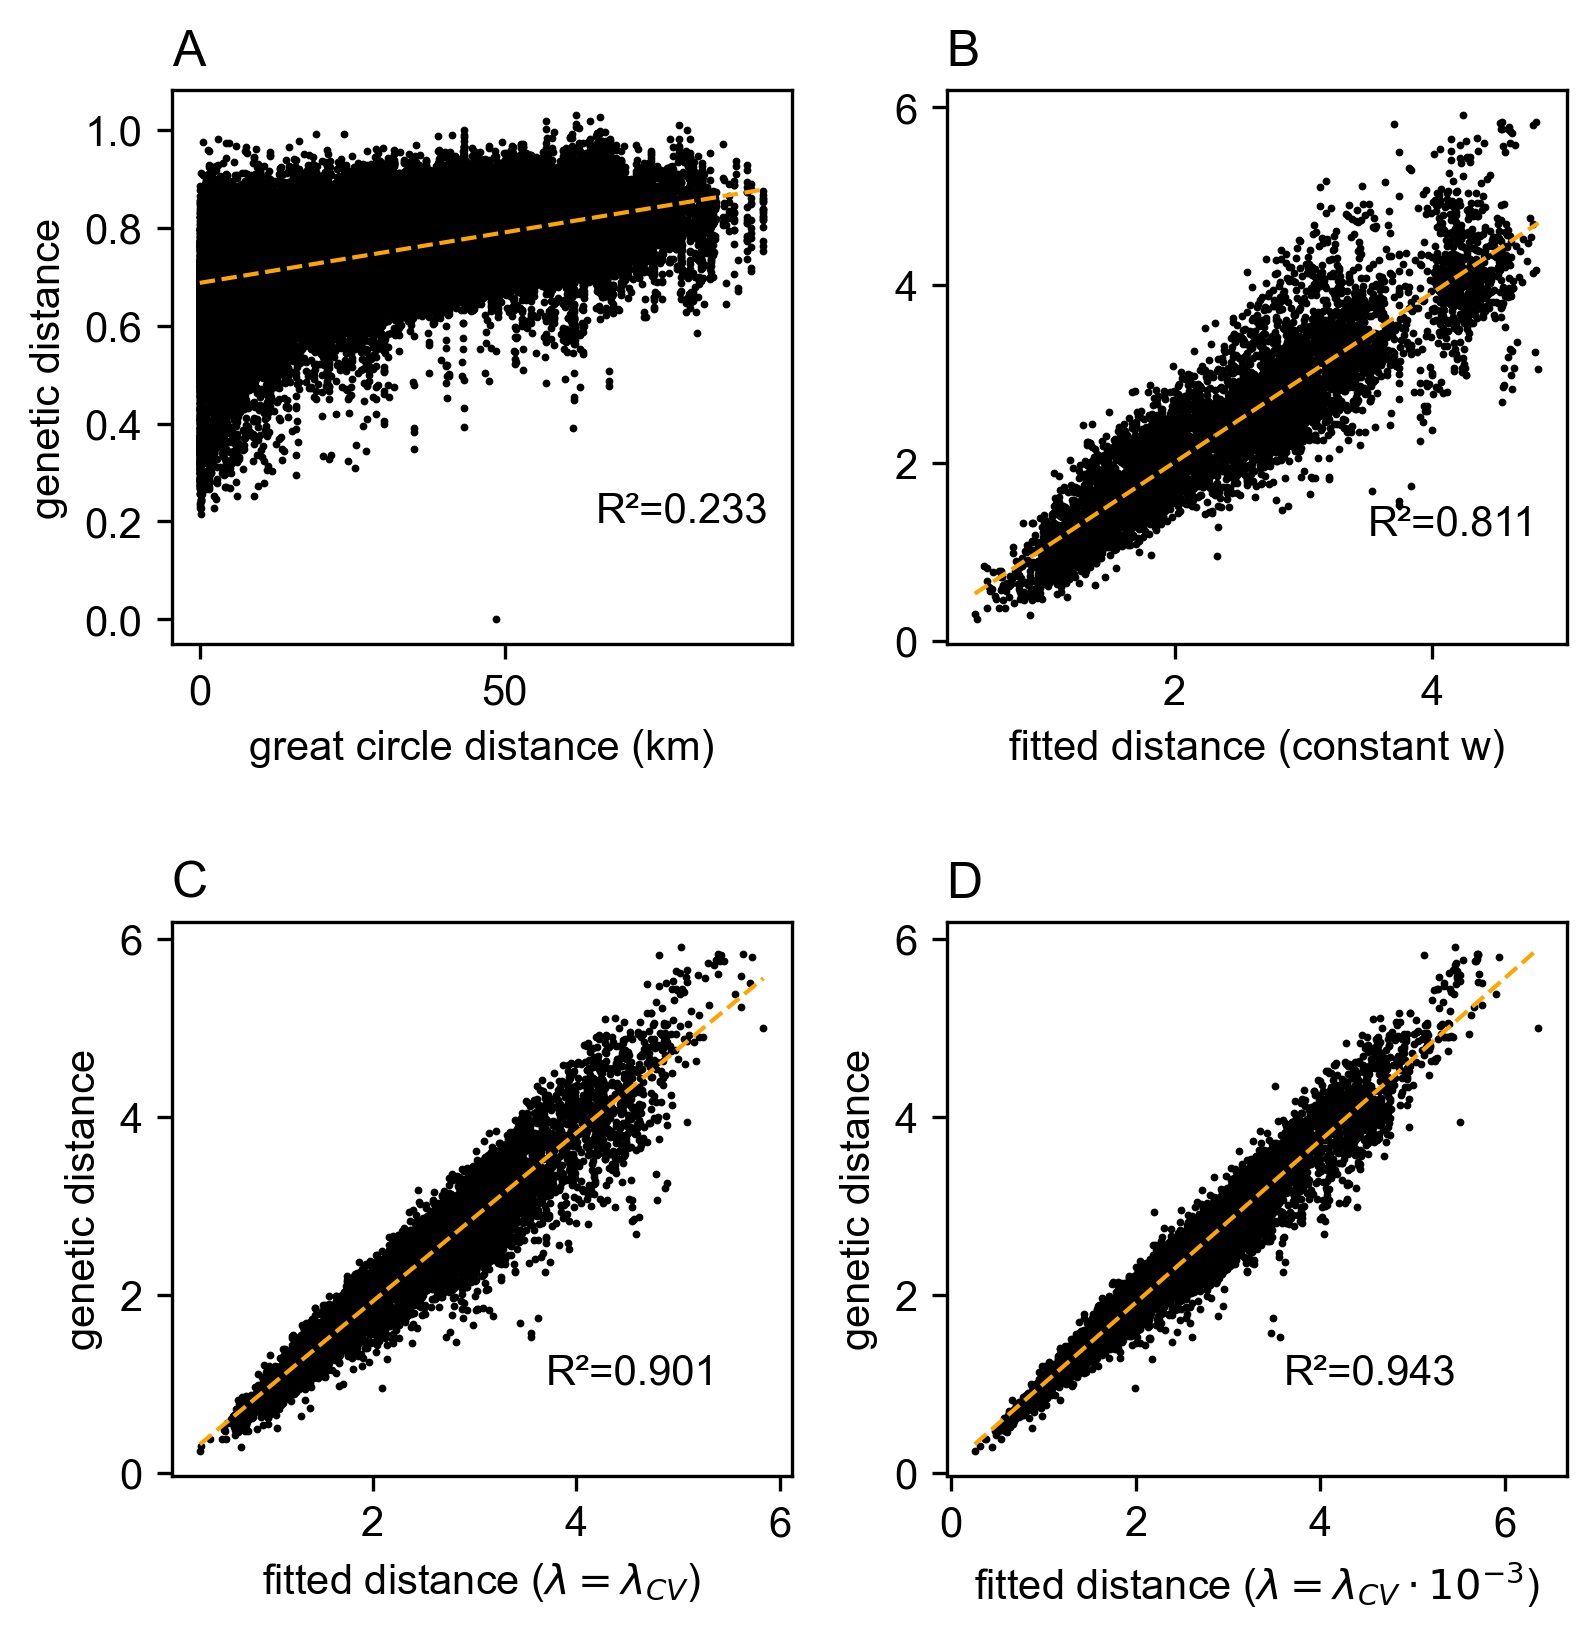

In [40]:
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics.pairwise import haversine_distances
import math
from feems import SpatialGraph, Viz, Objective, query_node_attributes
from feems.cross_validation import run_cv, comp_mats

n, p = genotypes.shape
lamb_cv = 5.30
def cov_to_dist(S):
    s2 = np.diag(S).reshape(-1, 1)
    ones = np.ones((s2.shape[0], 1))
    D = s2 @ ones.T + ones @ s2.T - 2 * S
    return(D)

# Initialize figure
# fig = plt.figure(constrained_layout=True, dpi=300, figsize=(6, 6))
# spec = gridspec.GridSpec(ncols=2, nrows=2, figure=fig)
fig = plt.figure(dpi=300, figsize=(6,6))
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=fig, wspace=0.25, hspace=0.5)

# (A) Genetic distance vs geographic distance
D_geno = squareform(pdist(genotypes, metric="sqeuclidean")) / p
coord_rad = coord[:,::-1] * math.pi / 180.0
D_geo = haversine_distances(coord_rad) * 6371000/1000
tril_idx = np.tril_indices(n, k=-1)
x = D_geo[tril_idx]
y = D_geno[tril_idx]
X = sm.add_constant(x)
mod = sm.OLS(y, X)
res = mod.fit()
muhat, betahat = res.params

ax_00 = fig.add_subplot(spec[0, 0])
ax_00.set_title("A", loc='left')
ax_00.scatter(x, 
              y, 
              marker=".", 
              alpha=1, 
              zorder=0, 
              color="black",
              s=3)

x_ = np.linspace(np.min(x), np.max(x), 20)
ax_00.plot(x_, muhat + betahat * x_, zorder=2, color="orange", linestyle='--', linewidth=1)
ax_00.text(65.0, 0.2, "R²={:.3f}".format(res.rsquared))
ax_00.set_xlabel("great circle distance (km)")
ax_00.set_ylabel("genetic distance")

# (B) Genetic distance vs fitted distance for constant w model 
tril_idx = np.tril_indices(sp_graph.n_observed_nodes, k=-1)
ax_01 = fig.add_subplot(spec[0, 1])
ax_01.set_title("B", loc='left')
sp_graph.fit_null_model()
sp_graph.comp_graph_laplacian(sp_graph.w)

obj = Objective(sp_graph)
fit_cov, _, emp_cov = comp_mats(obj)
fit_dist = cov_to_dist(fit_cov)[tril_idx]
emp_dist = cov_to_dist(emp_cov)[tril_idx]
X = sm.add_constant(fit_dist)
mod = sm.OLS(emp_dist, X)
res = mod.fit()
muhat, betahat = res.params
ax_01.scatter(fit_dist, 
              emp_dist, 
              marker=".", 
              alpha=1, 
              zorder=0, 
              color="black",
              s=3)

x_ = np.linspace(np.min(fit_dist), np.max(fit_dist), 20)
ax_01.plot(x_, muhat + betahat * x_, zorder=2, color="orange", linestyle='--', linewidth=1)
ax_01.text(3.5, 1.2, "R²={:.3f}".format(res.rsquared))
ax_01.set_xlabel("fitted distance (constant w)")

# (C) Genetic distance vs fitted distance for lambda = lambda_cv
tril_idx = np.tril_indices(sp_graph.n_observed_nodes, k=-1)
ax_10 = fig.add_subplot(spec[1, 0])
ax_10.set_title("C", loc='left')
lamb = lamb_cv
sp_graph.fit(lamb=lamb,
             lb=math.log(1e-6), 
             ub=math.log(1e+6))
sp_graph.comp_graph_laplacian(sp_graph.w)

obj = Objective(sp_graph)
fit_cov, _, emp_cov = comp_mats(obj)
fit_dist = cov_to_dist(fit_cov)[tril_idx]
emp_dist = cov_to_dist(emp_cov)[tril_idx]
X = sm.add_constant(fit_dist)
mod = sm.OLS(emp_dist, X)
res = mod.fit()
muhat, betahat = res.params
ax_10.scatter(fit_dist,
              emp_dist,
              marker=".", 
              alpha=1, 
              zorder=0, 
              color="black",
              s=3)

x_ = np.linspace(np.min(fit_dist), np.max(fit_dist), 20)
ax_10.plot(x_, muhat + betahat * x_, zorder=2, color="orange", linestyle='--', linewidth=1)
ax_10.text(3.7, 1, "R²={:.3f}".format(res.rsquared))
ax_10.set_xlabel("fitted distance ($\lambda = \lambda_{CV}$)")
ax_10.set_ylabel("genetic distance")

# (D) Genetic distance vs fitted distance for lambda = 1e-3*lambda_cv
tril_idx = np.tril_indices(sp_graph.n_observed_nodes, k=-1)
ax_11 = fig.add_subplot(spec[1, 1])
ax_11.set_title("D", loc='left')
lamb = 0.001*lamb_cv
sp_graph.fit(lamb=lamb,
             lb=math.log(1e-6), 
             ub=math.log(1e+6))
sp_graph.comp_graph_laplacian(sp_graph.w)

obj = Objective(sp_graph)
fit_cov, _, emp_cov = comp_mats(obj)
fit_dist = cov_to_dist(fit_cov)[tril_idx]
emp_dist = cov_to_dist(emp_cov)[tril_idx]
X = sm.add_constant(fit_dist)
mod = sm.OLS(emp_dist, X)
res = mod.fit()
muhat, betahat = res.params
ax_11.scatter(fit_dist,
              emp_dist,
              marker=".", 
              alpha=1, 
              zorder=0, 
              color="black",
              s=3)

x_ = np.linspace(np.min(fit_dist), np.max(fit_dist), 20)
ax_11.plot(x_, muhat + betahat * x_, zorder=2, color="orange", linestyle='--', linewidth=1)
ax_11.text(3.6, 1, "R²={:.3f}".format(res.rsquared))
ax_11.set_xlabel("fitted distance ($\lambda = \lambda_{CV}\cdot 10^{-3}$)")
ax_11.set_ylabel("genetic distance")
plt.savefig("./plots/feems/dgg2/p.feems.dgg2.best_5.30_fitted_distance.png", transparent=False)

constant-w/variance fit, converged in 116 iterations, train_loss=1149883.3027785
lambda=5.3000000, alpha=0.9151229, converged in 144 iterations, train_loss=1104679.5792438


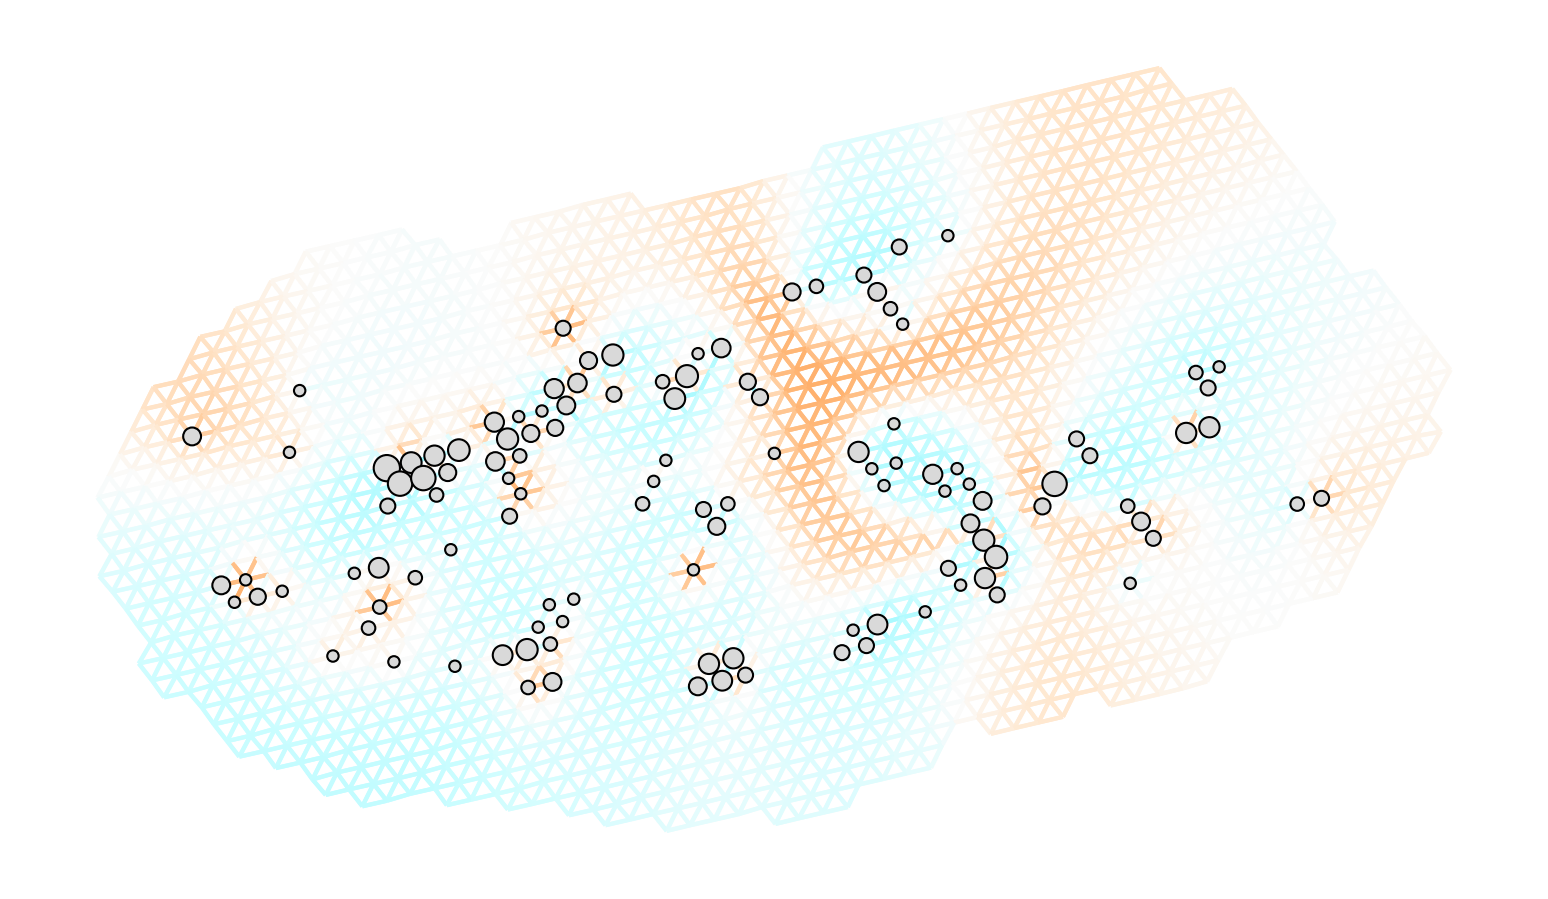

In [41]:
lamb_cv=5.30
sp_graph.fit(lamb = lamb_cv)
projection = ccrs.EquidistantConic(central_longitude=-83.5, central_latitude=35.6)
fig = plt.figure(dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=projection)  
v = Viz(ax, sp_graph, projection=projection, edge_width=1, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10)
# v.draw_map()
v.draw_obs_nodes(use_ids=False) 
v.draw_edges(use_weights=True)
plt.savefig("./plots/feems/dgg2/p.feems.dgg2.best_5.30_grid_transparent.png", transparent=True)
#v.draw_edge_colorbar()

In [26]:
sp_igraph = ig.Graph.from_networkx(sp_graph)


In [27]:
sp_igraph.write_graphml(f = "./plots/feems/dgg5/feems.dgg5.best_3.07.graph")

SystemError: <built-in method write_graphml of Graph object at 0x7fe8c28eb140> returned a result with an error set

Min empirical covariance -0.28
25th percentile empirical covariance -0.24
75th percentile empirical covariance -0.22
Max empirical covariance 0.74


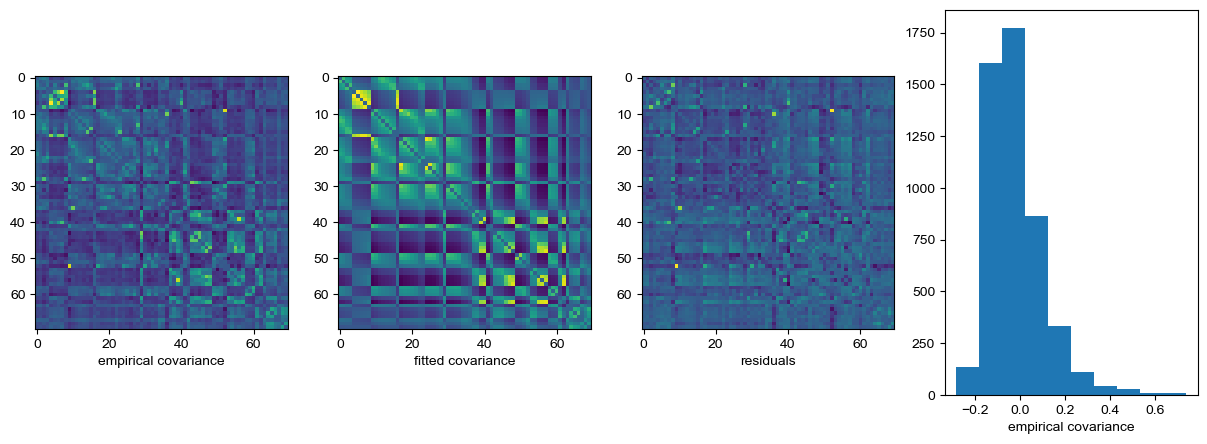

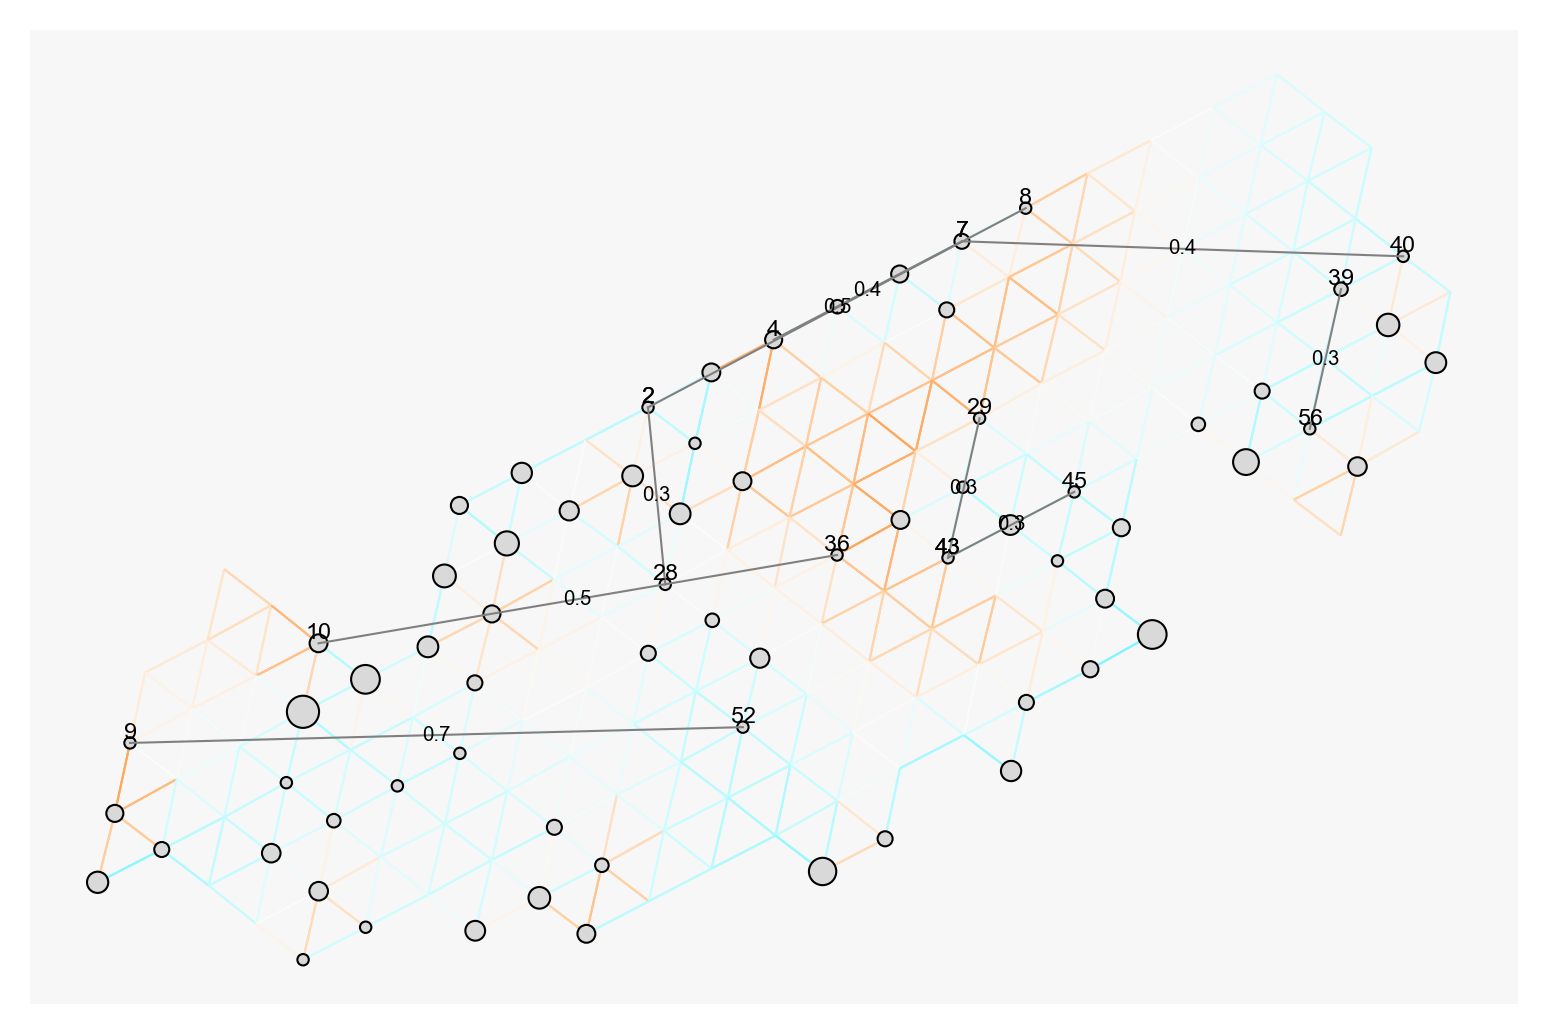

In [10]:
K = 10

# Plot Observed vs Fitted Covariances and residuals
obj = Objective(sp_graph)
fit_cov, _, emp_cov = comp_mats(obj)
# Set diagonals to zero to focus on covariances
np.fill_diagonal(fit_cov,0)
np.fill_diagonal(emp_cov,0)

# Plot matrices
fig = plt.figure(figsize = [15,5])
ax1 = fig.add_subplot(141)
ax1.imshow(emp_cov, interpolation='nearest')
ax1.set_xlabel("empirical covariance")
ax2 = fig.add_subplot(142)
ax2.imshow(fit_cov, interpolation='nearest')
ax2.set_xlabel("fitted covariance")
ax3 = fig.add_subplot(143)
ax3.imshow(emp_cov-fit_cov, interpolation='nearest')
ax3.set_xlabel("residuals")
ax4 = fig.add_subplot(144)
ax4.hist(emp_cov.flatten())
ax4.set_xlabel("empirical covariance")
print("Min empirical covariance {:.2f}".format(np.min(emp_cov)))
print("25th percentile empirical covariance {:.2f}".format(np.percentile(emp_cov,0.25)))
print("75th percentile empirical covariance {:.2f}".format(np.percentile(emp_cov,0.75)))
print("Max empirical covariance {:.2f}".format(np.max(emp_cov)))




# Plot the map with top K poorly fit covariances highlighted
fig = plt.figure(dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=projection)  
v = Viz(ax, sp_graph, projection=projection, edge_width=.5, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map()
v.draw_obs_nodes(use_ids=False) 
v.draw_edges(use_weights=True)
#v.draw_edge_colorbar()

# Compute matrix of residuals and order them
res_mat = emp_cov-fit_cov
iu1 = np.triu_indices(res_mat.shape[0])
res_mat[iu1] = 0
abs_res_mat = abs(res_mat)

res_ord=np.argsort(abs_res_mat,axis=None)

permuted_idx = query_node_attributes(v.sp_graph, "permuted_idx")
obs_perm_ids = permuted_idx[: v.sp_graph.n_observed_nodes]
obs_grid = v.grid[obs_perm_ids, :]
for i in range(1,K):
    pair = np.unravel_index(res_ord[-i], res_mat.shape)

    v.ax.plot(
        [obs_grid[pair[0], 0],obs_grid[pair[1],0]],
        [obs_grid[pair[0], 1],obs_grid[pair[1],1]],
        color = 'gray', linewidth = 0.5
    )
    v.ax.text(
        obs_grid[pair[0], 0],obs_grid[pair[0], 1], str(pair[0]),
        horizontalalignment="center", verticalalignment="bottom",
        size=v.obs_node_textsize*0.8, zorder=v.obs_node_zorder,
    )
    v.ax.text(
        obs_grid[pair[1], 0],obs_grid[pair[1], 1], str(pair[1]),
        horizontalalignment="center", verticalalignment="bottom",
        size=v.obs_node_textsize*0.8, zorder=v.obs_node_zorder,
    )
    v.ax.text(
        np.mean([obs_grid[pair[0], 0],obs_grid[pair[1], 0]]),
        np.mean([obs_grid[pair[0], 1],obs_grid[pair[1], 1]]),
        str("{:.1f}".format(res_mat[pair[0],pair[1]])),
        horizontalalignment="center",
        verticalalignment="center",
        size=v.obs_node_textsize*0.7
    )